In [ ]:
!pip install scikit-learn numpy matplotlib seaborn statsmodels
!pip install --upgrade pandas

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("datasets/CAR DETAILS FROM CAR DEKHO.csv")

In [82]:

pd.options.display.max_columns = None
pd.options.display.max_rows = None

In [83]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


In [85]:
df_clean = df.drop_duplicates()

<Axes: >

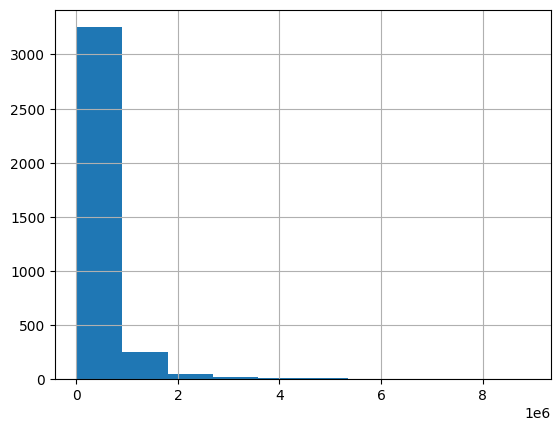

In [86]:
df_clean['selling_price'].hist()

In [87]:
df_clean['brand'] = df['name'].str.split().str[0]
df_clean.drop('name', axis=1, inplace=True)
df_clean['car_age'] = 2026 - df['year']
df_clean.drop('year', axis=1, inplace=True)
df_clean['log_selling_price'] = np.log(df_clean['selling_price'])
df_clean.drop('selling_price',axis=1,inplace=True)

<Axes: xlabel='owner', ylabel='log_selling_price'>

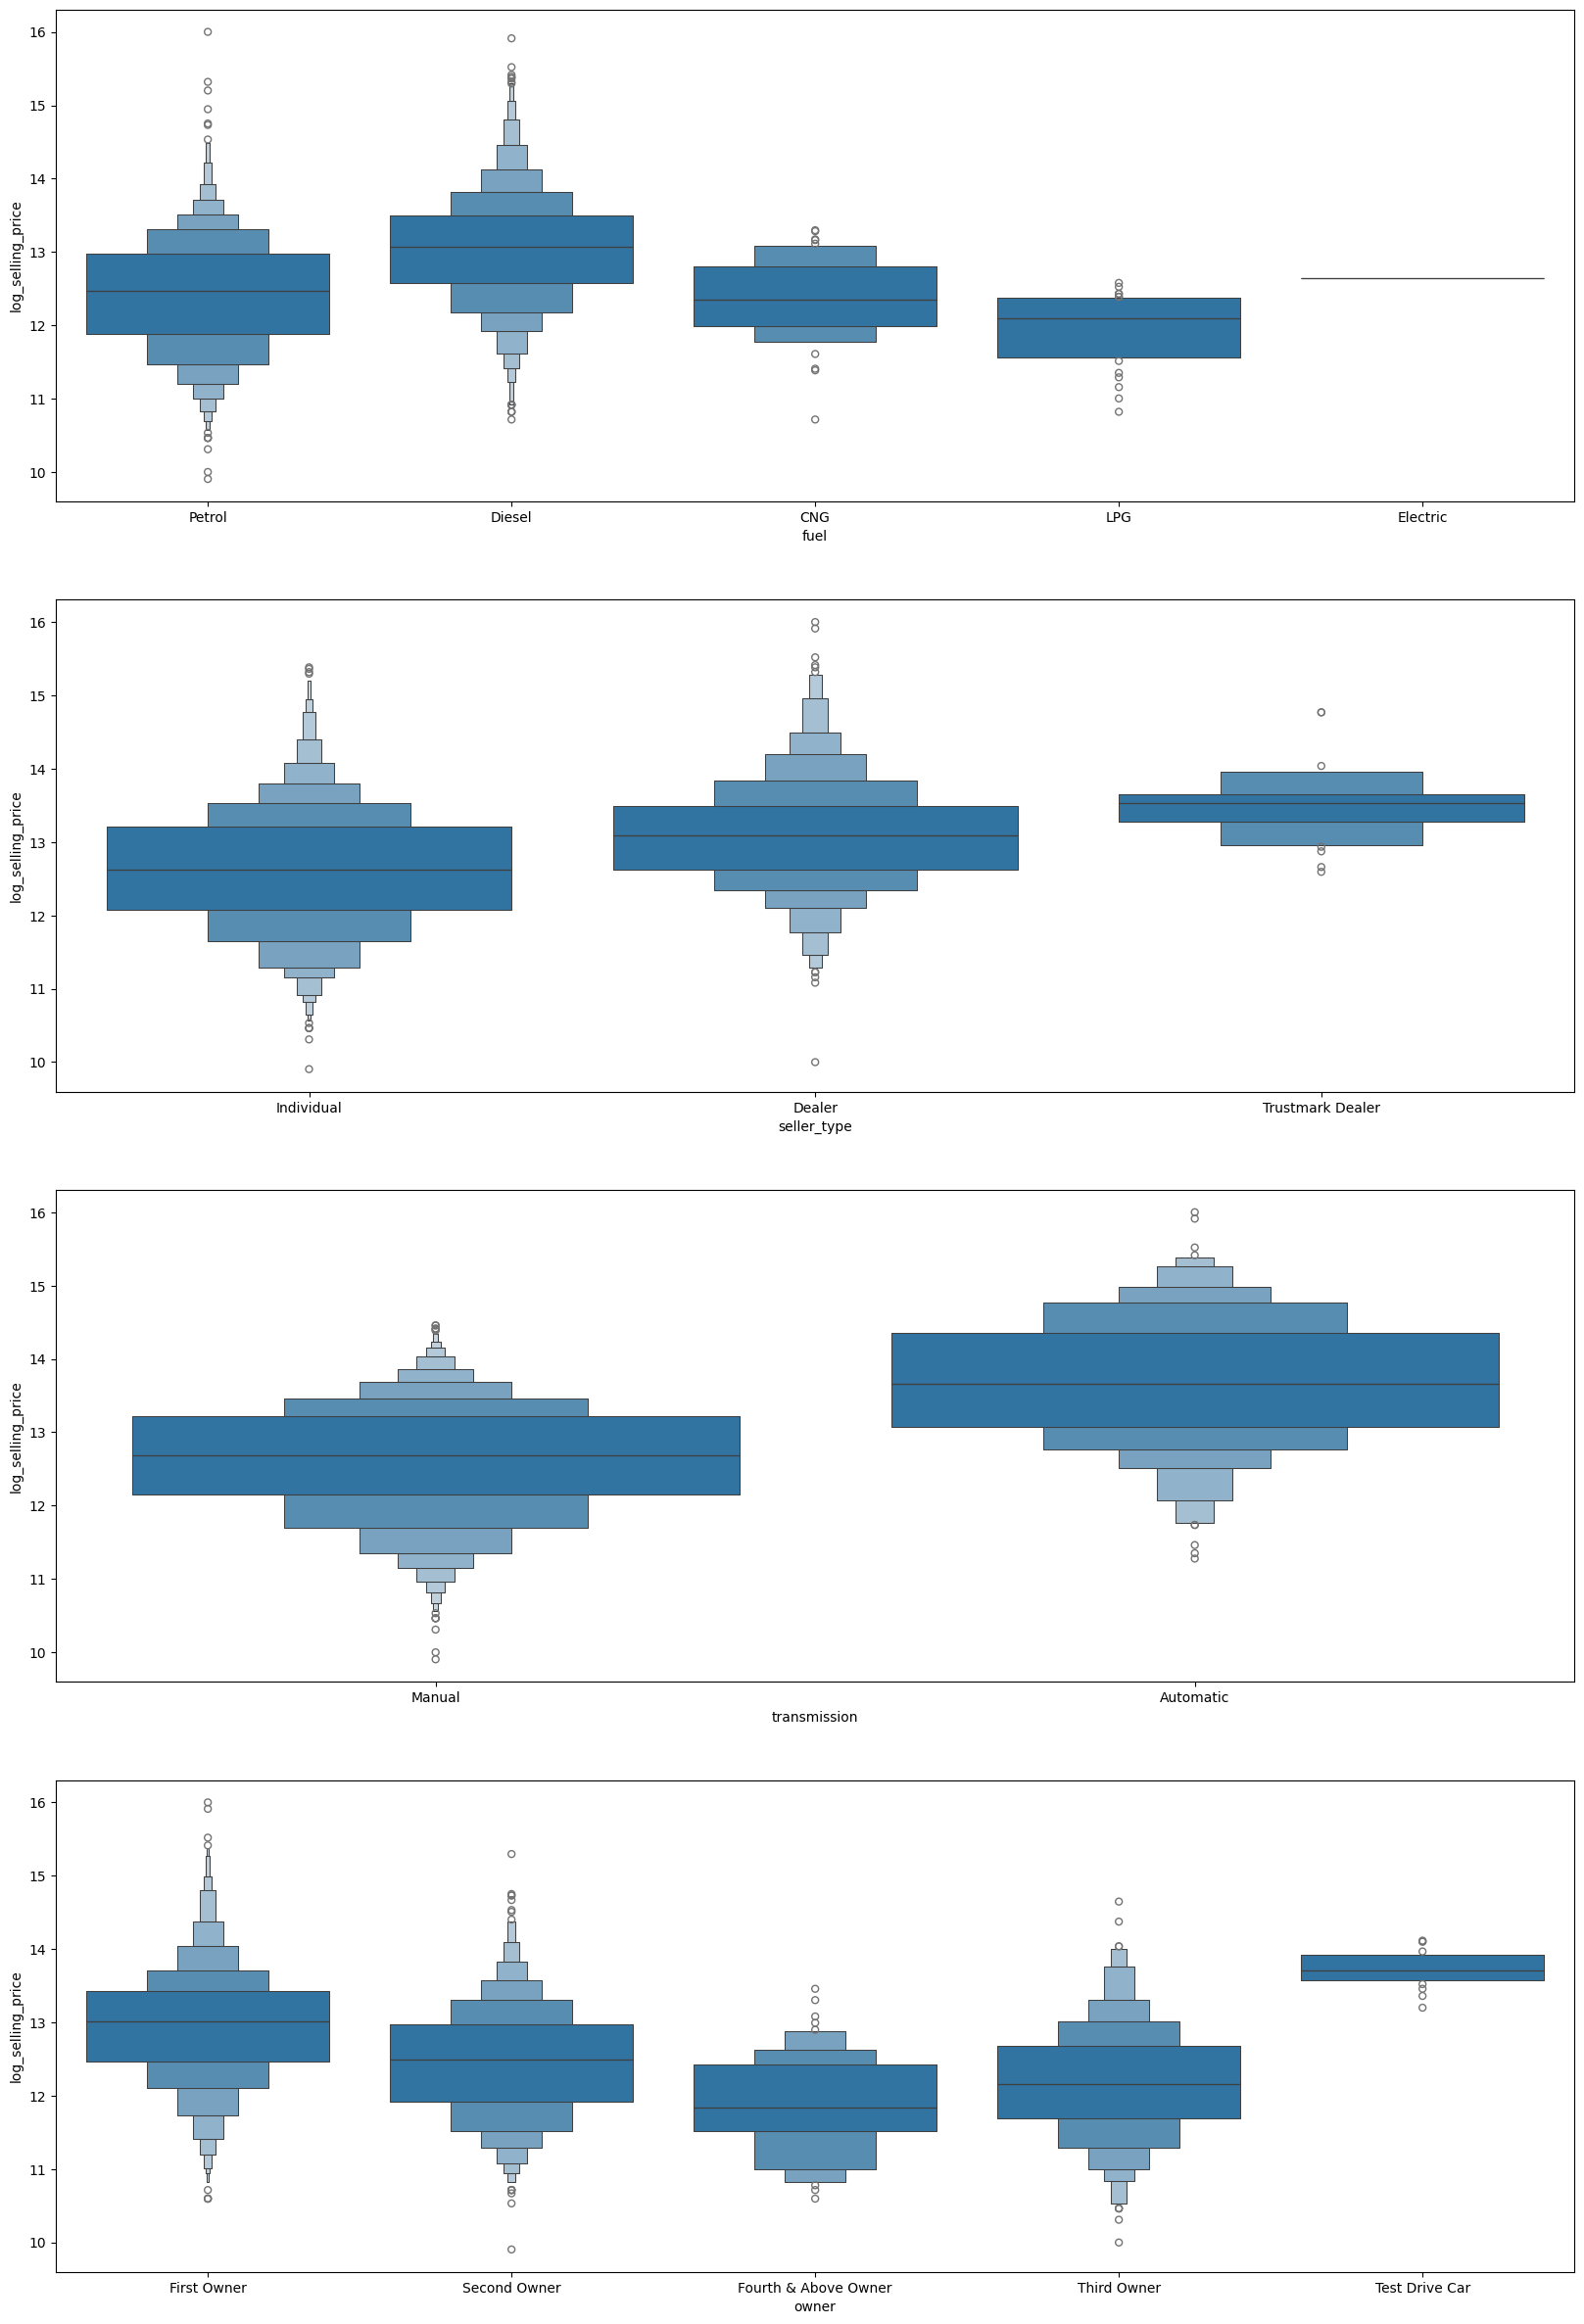

In [89]:
fig, ax = plt.subplots(4,1,figsize=(20,30))
sns.boxenplot(df_clean, x='fuel', y='log_selling_price', ax=ax[0])
sns.boxenplot(df_clean, x='seller_type', y='log_selling_price', ax=ax[1])
sns.boxenplot(df_clean, x='transmission', y='log_selling_price', ax=ax[2])
sns.boxenplot(df_clean, x='owner', y='log_selling_price', ax=ax[3])

<Axes: xlabel='car_age', ylabel='log_selling_price'>

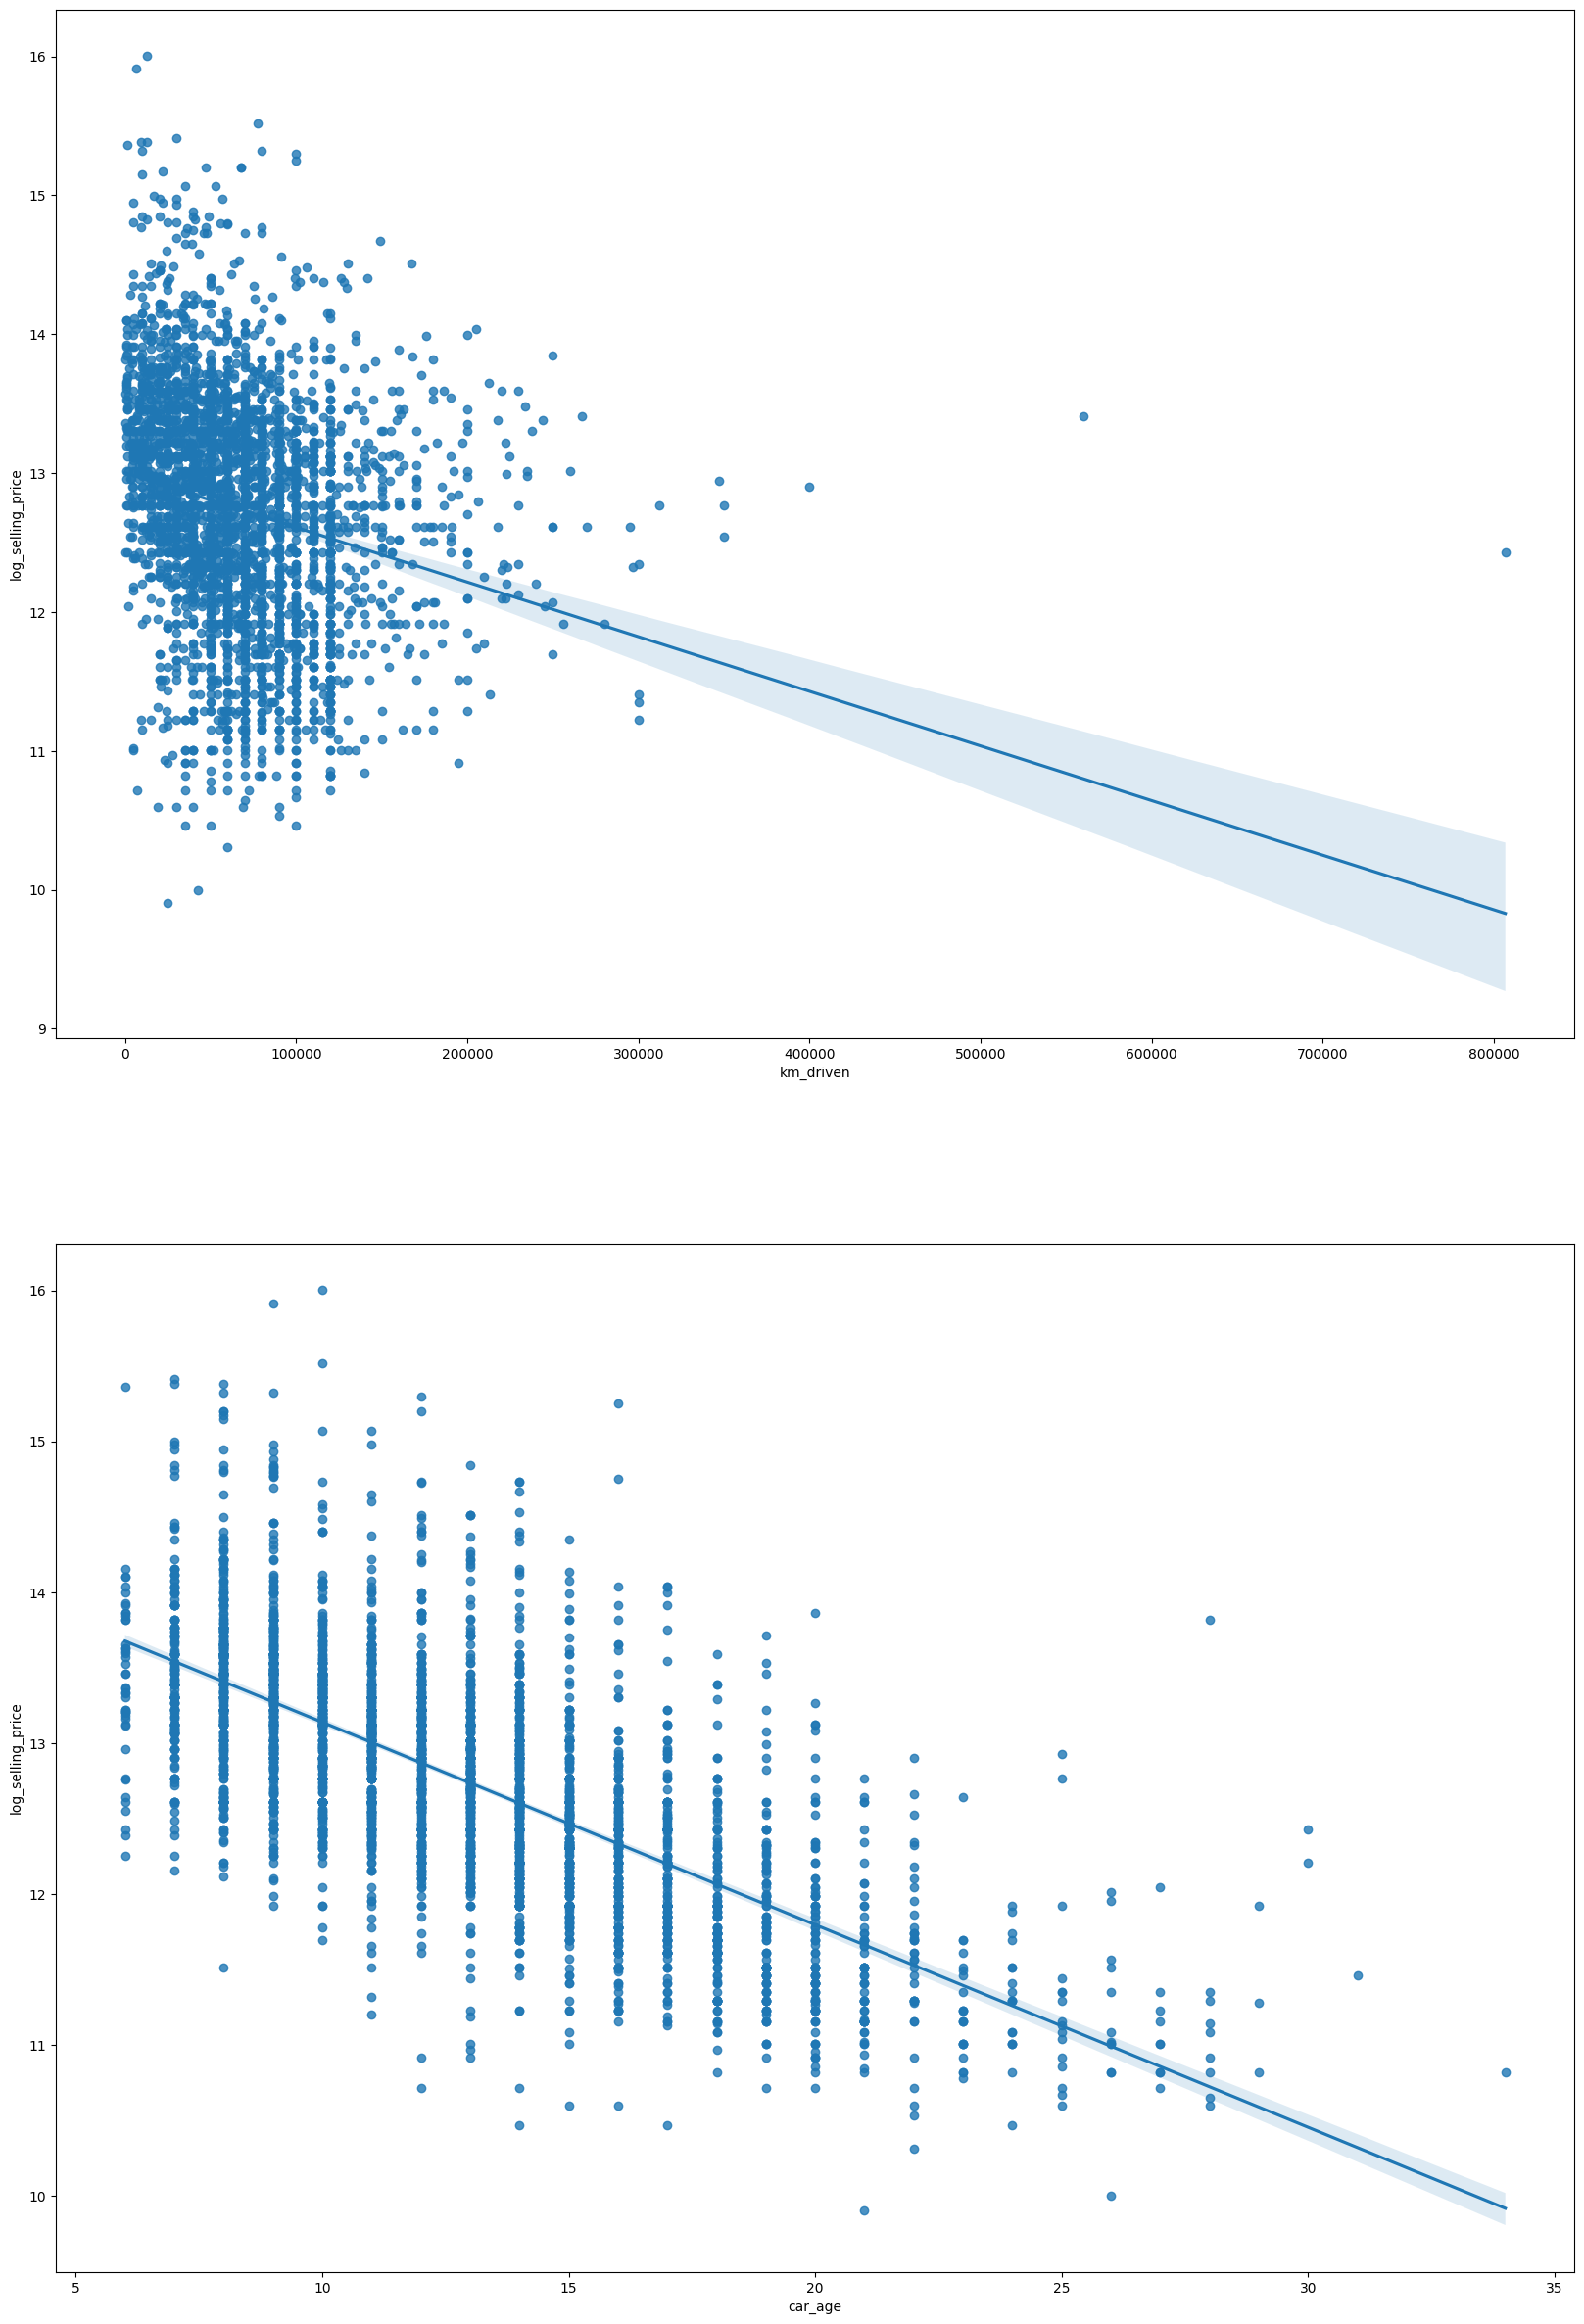

In [91]:
fig, ax = plt.subplots(2,1,figsize=(20,30))
sns.regplot(df_clean, x='km_driven', y='log_selling_price', ax = ax[0])
sns.regplot(df_clean, x='car_age', y='log_selling_price', ax = ax[1])


<Axes: >

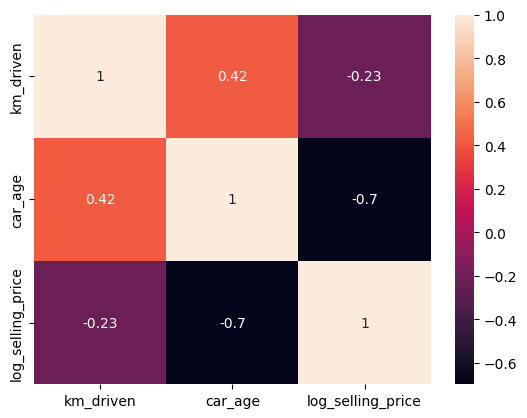

In [92]:
sns.heatmap(df_clean.corr(numeric_only=True),annot=True)

In [93]:
df_dum = pd.get_dummies(df_clean, drop_first=True)

In [94]:
from sklearn.model_selection import train_test_split

X = df_dum.drop("log_selling_price",axis=1)
y = df_dum["log_selling_price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [95]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2:", r2_score(y_test,pred))
print("mean absolute error:", mean_absolute_error(y_test,pred))

R2: 0.7758023044129948
mean absolute error: 0.307864982557798


In [96]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

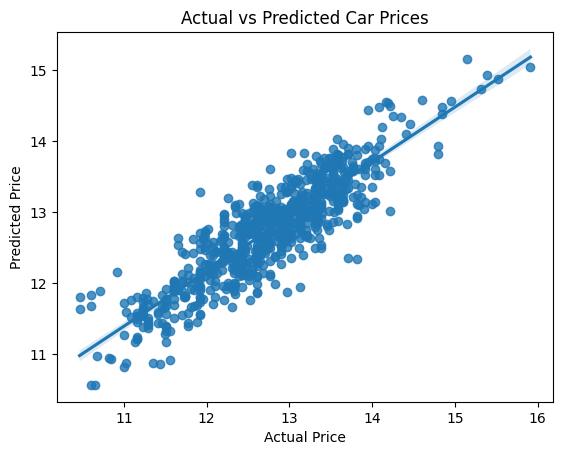

In [97]:
sns.regplot(x=y_test, y=pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

In [ ]:
# a positive regplot of actual vs predicted tells that the model is working correctly
# points tight to the line: High accuracy (low error).
# while points far from the line: Low accuracy (high error/noise), even if the trend is positive.
# The 45-degree angle: Ideally, the line should be at a 45-degree angle

In [ ]:
#HOWEVER
# the nature of the dataset doesnt seem to fit the purpose of linear regression model
# thinking about it more, 
# as there are many categorical columns or variables and the fact that the cars are used
# the selling price varies on the state and features of the car
# the state of the car depends on its quality part of it is its brand, its age and how many times it was passed down
    # often depending on the brand the higher the selling price could be
# another factor would be the features of the car 
    # such as the fuel and transmission type (included on the dataset)
# although a missing factor would be what possibly the issues the car has that could affect the price
    # but since the cars are being sold, I don't think anyone would tell what issues the car have

# trying decision tree model next

In [ ]:
residuals = y_test - pred

plt.scatter(pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
sns.regplot(x="km_driven", y="log_selling_price", data=df_dum)
plt.show()

In [ ]:
importance.sort_values(by="Coefficient", inplace=True)

importance.plot.barh(x="Feature", y="Coefficient")
plt.title("Feature Importance")
plt.show()